# 沐曦GPU运行M3D-LaMed说明文档

[M3D-LaMed](https://github.com/BAAI-DCAI/M3D) 是面向三维医学图像分析的多模态大语言模型，使用 M3D-CLIP 视觉编码器连接三维医学图像和语言模型，支持医学图像描述、视觉问答、目标定位框和器官分割等任务。

[M3D-LaMed](https://github.com/BAAI-DCAI/M3D) 由第三方以开源许可证发布，我方未对其源代码作任何修改。您可通过以下链接 [https://github.com/BAAI-DCAI/M3D](https://github.com/BAAI-DCAI/M3D) 查阅该项目的源代码、许可证全文、版权与归属声明及其他项目文档。

本教程随附的上游许可证文本见 `LICENSE`（MIT）；Hugging Face 模型卡对 `M3D-LaMed-Phi-3-4B` 标注为 Apache-2.0，权重使用和再分发请同时遵守模型卡及原始项目条款。

本教程直接使用官方 Hugging Face `AutoTokenizer` 与 `AutoModelForCausalLM` 接口，不调用上游 demo 脚本。每个推理代码单元只执行一个任务；示例输入来自 M3D 仓库公开的 `Data/data/examples` 样例（报告 `example_00.npy`、VQA `example_01.npy`、定位 `example_03.npy`、分割 `example_04.npy`），模型权重需由使用者按模型卡自行准备。输出仅用于软件配置、工程和研究验证，不用于诊断、治疗建议或临床决策。


## 1. 安装

### 1.1 环境准备

使用沐曦开发者社区提供的 [maca-pytorch 镜像](https://developer.metax-tech.com/softnova/docker?chip_name=%E6%9B%A6%E4%BA%91C500%E7%B3%BB%E5%88%97&package_name=maca-pytorch:3.8.0.11-torch2.6-py310-ubuntu24.04-amd64) 启动容器：

```bash
docker run -it --name m3d-lamed --device=/dev/mxcd --device=/dev/dri \
  --group-add video --shm-size=8G --security-opt seccomp=unconfined \
  --ulimit memlock=-1 --ulimit stack=67108864 \
  -v "$(pwd)":/workspace/m3d \
  cr.metax-tech.com/public-library/maca-pytorch:3.8.0.11-torch2.6-py310-ubuntu24.04-amd64 /bin/bash
```

**参数说明：**

- `--device=/dev/mxcd --device=/dev/dri`：挂载沐曦 GPU 设备；
- `--group-add video`：添加 video 组以访问 GPU；
- `--shm-size=8G`：设置共享内存大小；
- `-v "$(pwd)":/workspace/m3d`：把当前教程目录挂载到容器；示例数据和模型权重按下文命令准备到该目录。

> 如需使用更新版本，请访问[沐曦开发者社区镜像资源中心](https://developer.metax-tech.com/softnova/docker/)获取对应资源。

### 1.2 安装

安装命令仅作环境准备说明，本 Notebook 不自动执行安装或下载：

```bash
cd /opt
git clone https://github.com/BAAI-DCAI/M3D.git
cd M3D
# 保留镜像内已验证的 MACA PyTorch，不安装 CUDA 版 torch/torchvision
sed -i '/^torch==/d; /^torchvision==/d; /^xformers==/d' requirements.txt
python -m pip install -r requirements.txt
python -m pip install 'transformers>=4.42,<4.43' sentencepiece protobuf
python -m pip install -U 'huggingface_hub[cli]'
python -m pip install jupyter
```

### 1.3 准备官方示例数据

上一节从官方 M3D 仓库执行 `git clone` 时已包含 `Data/data/examples` 目录和示例数组，无需再次下载或执行额外的数据准备命令。推理使用其中的 `example_00.npy`（报告）、`example_01.npy`（VQA）、`example_03.npy`（定位）和 `example_04.npy`（分割）。

### 1.4 下载真实模型权重

在容器内使用 Hugging Face 官方下载工具获取真实权重。下面以官方推荐的 Phi-3-4B 版本为例；若显存和授权条件允许，也可以下载 Llama-2-7B 版本。下载命令会把配置、Tokenizer、视觉编码器和模型权重完整保存到 Notebook 使用的路径：

```bash
export HF_HOME=/workspace/m3d/.cache/huggingface
hf download GoodBaiBai88/M3D-LaMed-Phi-3-4B \
  --local-dir /workspace/m3d/models/M3D-LaMed-Phi-3-4B \
  --max-workers 2

```

Llama-2-7B 版本的命令为：

```bash
hf download GoodBaiBai88/M3D-LaMed-Llama-2-7B \
  --local-dir /workspace/m3d/models/M3D-LaMed-Llama-2-7B \
  --max-workers 2
```

下载完成后，设置模型路径（默认值已经与第一条命令一致）：

```bash
export M3D_MODEL_DIR=/workspace/m3d/models/M3D-LaMed-Phi-3-4B

# 确认语言模型分片、视觉投影和分割权重均已落盘：
ls -lh "$M3D_MODEL_DIR"/model-*.safetensors \
  "$M3D_MODEL_DIR"/mm_projector.bin "$M3D_MODEL_DIR"/model.bin
```

下载命令必须在有网络的环境中执行；Notebook 推理使用 `local_files_only=True`，因此不会以隐式网络下载替代真实本地权重。模型权重不随本 Notebook 分发。


### 1.5 环境验证

In [1]:
import torch

assert torch.cuda.is_available(), "未检测到沐曦 GPU，请检查 /dev/mxcd 和 /dev/dri 映射。"
print("PyTorch version:", torch.__version__)
print("CUDA OK:", torch.cuda.get_device_name(0))

from transformers import AutoTokenizer, AutoModelForCausalLM
print("Transformers import: OK")


PyTorch version: 2.6.0+metax3.8.0.7
CUDA OK: MetaX C500
Transformers import: OK


## 2. 沐曦GPU 运行效果展示

以下单元从同一组参数锚点读取模型和任务输入。官方示例数组均按 `(1, 32, 256, 256)` 送入模型，轴序为 `(channel, depth, height, width)`，强度为归一化后的浮点值；定位和分割分别使用官方对应任务样例，以确保目标器官实际存在。

加载 M3D-LaMed 模型并准备官方示例输入：

In [2]:
import os
import random
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

MODEL_DIR = os.environ.get("M3D_MODEL_DIR", "/workspace/m3d/models/M3D-LaMed-Phi-3-4B")
REPORT_IMAGE_PATH = Path(os.environ.get(
    "M3D_REPORT_INPUT_PATH", "/workspace/m3d/Data/data/examples/example_00.npy"
))
VQA_IMAGE_PATH = Path(os.environ.get(
    "M3D_VQA_INPUT_PATH", "/workspace/m3d/Data/data/examples/example_01.npy"
))
POSITIONING_IMAGE_PATH = Path(os.environ.get(
    "M3D_POSITIONING_INPUT_PATH", "/workspace/m3d/Data/data/examples/example_03.npy"
))
SEGMENTATION_IMAGE_PATH = Path(os.environ.get(
    "M3D_SEGMENTATION_INPUT_PATH", "/workspace/m3d/Data/data/examples/example_04.npy"
))
DEVICE = torch.device("cuda:0")
DTYPE = torch.bfloat16
PROJ_OUT_NUM = 256
MAX_NEW_TOKENS = 128
DO_SAMPLE = False
TOP_P = None
TEMPERATURE = 1.0

print("model:", MODEL_DIR)
print("report input:", REPORT_IMAGE_PATH)
print("vqa input:", VQA_IMAGE_PATH)
print("positioning input:", POSITIONING_IMAGE_PATH)
print("segmentation input:", SEGMENTATION_IMAGE_PATH)
print("device:", DEVICE)
print("GPU:", torch.cuda.get_device_name(0))

for input_path in [REPORT_IMAGE_PATH, VQA_IMAGE_PATH, POSITIONING_IMAGE_PATH, SEGMENTATION_IMAGE_PATH]:
    if not input_path.is_file():
        raise FileNotFoundError(f"找不到输入文件: {input_path}")
model_root = Path(MODEL_DIR)
if not model_root.is_dir():
    raise FileNotFoundError(f"找不到本地模型目录: {model_root}；请先执行 1.3 的权重下载命令")
weight_files = list(model_root.glob("*.safetensors")) + list(model_root.glob("*.bin"))
if not weight_files:
    raise FileNotFoundError(f"{model_root} 中没有模型权重文件；请勿使用随机初始化或 mock 权重")
print("checkpoint files:", len(weight_files))

def load_image(input_path):
    image = np.load(input_path).astype(np.float32)
    if image.ndim == 3:
        image = image[None, ...]
    if image.shape != (1, 32, 256, 256):
        raise ValueError(f"官方入口要求 (1, 32, 256, 256)，实际为 {image.shape}")
    if not np.isfinite(image).all() or image.min() < 0 or image.max() > 1:
        raise ValueError("输入必须是有限且归一化到 [0, 1] 的浮点数组")
    return image

report_np = load_image(REPORT_IMAGE_PATH)
vqa_np = load_image(VQA_IMAGE_PATH)
positioning_np = load_image(POSITIONING_IMAGE_PATH)
segmentation_np = load_image(SEGMENTATION_IMAGE_PATH)

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_DIR,
    model_max_length=512,
    padding_side="right",
    use_fast=False,
    trust_remote_code=True,
    local_files_only=True,
)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_DIR,
    torch_dtype=DTYPE,
    trust_remote_code=True,
    local_files_only=True,
)
model = model.to(device=DEVICE)
model.eval()
report_pt = torch.from_numpy(report_np).unsqueeze(0).to(device=DEVICE, dtype=DTYPE)
vqa_pt = torch.from_numpy(vqa_np).unsqueeze(0).to(device=DEVICE, dtype=DTYPE)
positioning_pt = torch.from_numpy(positioning_np).unsqueeze(0).to(device=DEVICE, dtype=DTYPE)
segmentation_pt = torch.from_numpy(segmentation_np).unsqueeze(0).to(device=DEVICE, dtype=DTYPE)
print("input shapes:", report_np.shape, vqa_np.shape, positioning_np.shape, segmentation_np.shape)
print("tensor shape:", tuple(report_pt.shape), report_pt.dtype, report_pt.device)
print("model loaded:", model.__class__.__name__)
print("language/vision/segmentation parameters loaded from local checkpoint")


model: /workspace/m3d/models/M3D-LaMed-Phi-3-4B
report input: /workspace/m3d/Data/data/examples/example_00.npy
vqa input: /workspace/m3d/Data/data/examples/example_01.npy
positioning input: /workspace/m3d/Data/data/examples/example_03.npy
segmentation input: /workspace/m3d/Data/data/examples/example_04.npy
device: cuda:0
GPU: MetaX C500
checkpoint files: 6
build_sam_vit_3d...
input shapes: (1, 32, 256, 256) (1, 32, 256, 256) (1, 32, 256, 256) (1, 32, 256, 256)
tensor shape: (1, 1, 32, 256, 256) torch.bfloat16 cuda:0
model loaded: LamedPhi3ForCausalLM
language/vision/segmentation parameters loaded from local checkpoint


displayed report input: /workspace/m3d/Data/data/examples/example_00.npy


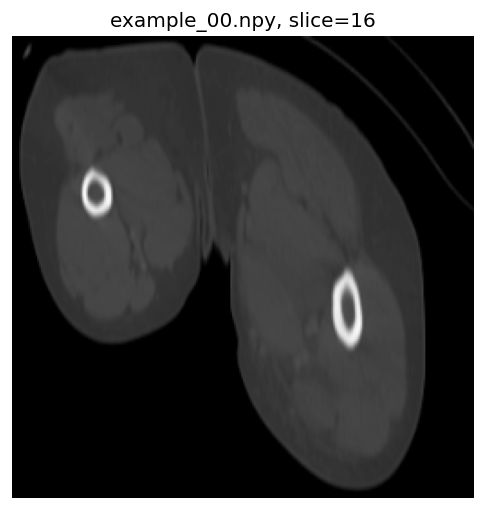

In [3]:
# 显示报告任务实际使用的输入中间切片
report_mid = report_np.shape[1] // 2
fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(report_np[0, report_mid], cmap="gray", vmin=0, vmax=1)
ax.set_title(f"{REPORT_IMAGE_PATH.name}, slice={report_mid}")
ax.axis("off")
plt.show()
print("displayed report input:", REPORT_IMAGE_PATH)


Running inference for report generation:

In [4]:
question_report = "Please generate a medical report based on this image."
image_tokens_report = "<im_patch>" * PROJ_OUT_NUM
input_txt_report = image_tokens_report + question_report
input_id_report = tokenizer(input_txt_report, return_tensors="pt")["input_ids"].to(DEVICE)

with torch.inference_mode():
    generation_report = model.generate(
        report_pt,
        input_id_report,
        max_new_tokens=MAX_NEW_TOKENS,
        do_sample=DO_SAMPLE,
        top_p=TOP_P,
        temperature=TEMPERATURE,
    )

report_text = tokenizer.batch_decode(generation_report, skip_special_tokens=True)[0]
print("task: report_generation")
print("question:", question_report)
print("generated_text:", report_text)


task: report_generation
question: Please generate a medical report based on this image.
generated_text: CT shows a large and eccentric geographic lesion of the posterior medial aspect of the lower femoral diaphysis with medullary expansion. The cortex is thinned out with no evidence of cortical breach. The femoral cortex is preserved. No adjacent soft tissue abnormality. The knee joint is unremarkable.


Running inference for open-ended visual question answering:

In [5]:
question_vqa = "What is the abnormality type in this image?"
image_tokens_vqa = "<im_patch>" * PROJ_OUT_NUM
input_txt_vqa = image_tokens_vqa + question_vqa
input_id_vqa = tokenizer(input_txt_vqa, return_tensors="pt")["input_ids"].to(DEVICE)

with torch.inference_mode():
    generation_vqa = model.generate(
        vqa_pt,
        input_id_vqa,
        max_new_tokens=MAX_NEW_TOKENS,
        do_sample=DO_SAMPLE,
        top_p=TOP_P,
        temperature=TEMPERATURE,
    )

vqa_text = tokenizer.batch_decode(generation_vqa, skip_special_tokens=True)[0]
print("task: open_ended_vqa")
print("question:", question_vqa)
print("generated_text:", vqa_text)


task: open_ended_vqa
question: What is the abnormality type in this image?
generated_text: A well-defined homogeneous fat density lesion (measuring 16 x 37 mm) is seen at the right submandibular region anterior to the right submandibular gland and inferolateral to the anterior belly of the right digastric muscle. No internal septae, calcifications or enhancing soft tissue components noted. Findings are typical for a lipoma.


Running inference for target positioning:

task: positioning
question: Where is liver in this image? Please output the box.
generated_text: The bounding box is given by [0.562, 0.32, 0.438, 0.938, 0.898, 0.891].
box (z0, y0, x0, z1, y1, x1): [0.562, 0.32, 0.438, 0.938, 0.898, 0.891]


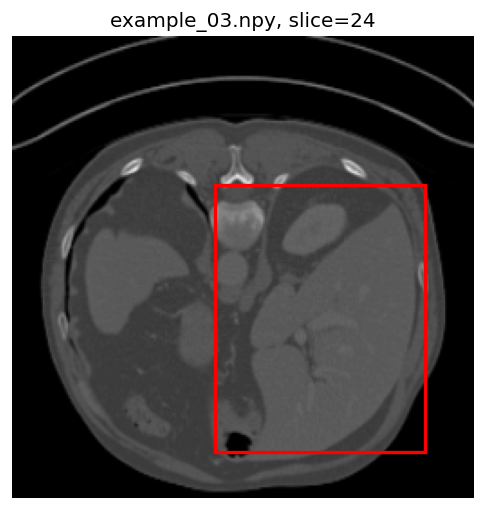

In [6]:
question_box = "Where is liver in this image? Please output the box."
image_tokens_box = "<im_patch>" * PROJ_OUT_NUM
input_txt_box = image_tokens_box + question_box
input_id_box = tokenizer(input_txt_box, return_tensors="pt")["input_ids"].to(DEVICE)

with torch.inference_mode():
    generation_box = model.generate(
        positioning_pt,
        input_id_box,
        max_new_tokens=MAX_NEW_TOKENS,
        do_sample=DO_SAMPLE,
        top_p=TOP_P,
        temperature=TEMPERATURE,
    )

box_text = tokenizer.batch_decode(generation_box, skip_special_tokens=True)[0]
box_match = re.search(r"\[([-+]?\d*\.?\d+), ([-+]?\d*\.?\d+), ([-+]?\d*\.?\d+), ([-+]?\d*\.?\d+), ([-+]?\d*\.?\d+), ([-+]?\d*\.?\d+)\]", box_text)
if box_match is None:
    raise ValueError(f"模型未返回六维定位框: {box_text}")
box = [float(value) for value in box_match.groups()]
z0, y0, x0, z1, y1, x1 = [box[0] * 32, box[1] * 256, box[2] * 256, box[3] * 32, box[4] * 256, box[5] * 256]
positioning_slice = int(round((z0 + z1) / 2))
from matplotlib.patches import Rectangle
fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(positioning_np[0, positioning_slice], cmap="gray", vmin=0, vmax=1)
ax.add_patch(Rectangle((x0, y0), x1 - x0, y1 - y0, fill=False, edgecolor="red", linewidth=2))
ax.set_title(f"{POSITIONING_IMAGE_PATH.name}, slice={positioning_slice}")
ax.axis("off")
plt.show()
print("task: positioning")
print("question:", question_box)
print("generated_text:", box_text)
print("box (z0, y0, x0, z1, y1, x1):", box)


Running inference for organ segmentation:

task: segmentation
question: Can you segment the lung in this image? Please output the mask.
generated_text: The segmentation reveals  [SEG] .
mask shape: (32, 256, 256)
positive voxels: 74189
overlay slice: 31
overlay positive voxels: 19121


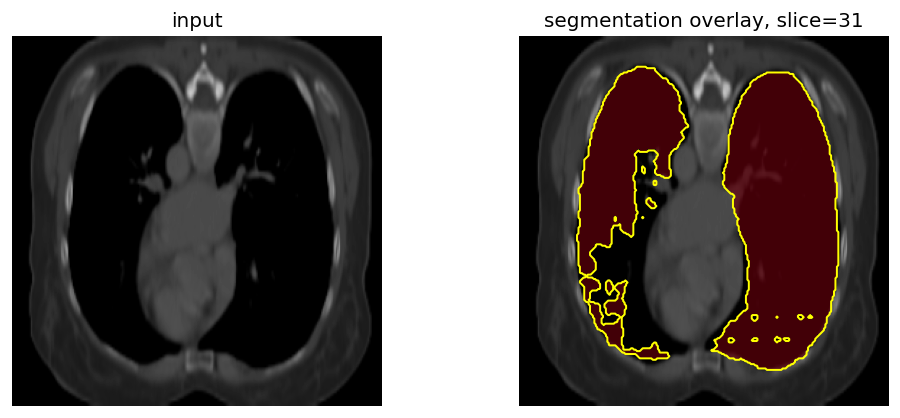

In [7]:
question_seg = "Can you segment the lung in this image? Please output the mask."
image_tokens_seg = "<im_patch>" * PROJ_OUT_NUM
input_txt_seg = image_tokens_seg + question_seg
input_id_seg = tokenizer(input_txt_seg, return_tensors="pt")["input_ids"].to(DEVICE)

with torch.inference_mode():
    generation_seg, seg_logit = model.generate(
        segmentation_pt,
        input_id_seg,
        seg_enable=True,
        max_new_tokens=MAX_NEW_TOKENS,
        do_sample=DO_SAMPLE,
        top_p=TOP_P,
        temperature=TEMPERATURE,
    )

seg_text = tokenizer.batch_decode(generation_seg, skip_special_tokens=True)[0]
seg_mask = (torch.sigmoid(seg_logit) > 0.5).detach().float().cpu().numpy()
if seg_mask.ndim == 5:
    mask = seg_mask[0, 0]
elif seg_mask.ndim == 4:
    mask = seg_mask[0]
else:
    raise ValueError(f"模型分割输出形状异常: {seg_mask.shape}")
if mask.shape != segmentation_np.shape[1:]:
    raise ValueError(f"掩膜与输入空间形状不一致: {mask.shape} vs {segmentation_np.shape[1:]}")
if int(mask.sum()) == 0:
    raise ValueError("模型返回空分割掩膜，请更换为官方分割样例")

segmentation_slice = int(np.argmax(mask.reshape(mask.shape[0], -1).sum(axis=1)))
slice_mask = np.ma.masked_where(mask[segmentation_slice] <= 0, mask[segmentation_slice])
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].imshow(segmentation_np[0, segmentation_slice], cmap="gray", vmin=0, vmax=1)
ax[0].set_title("input")
ax[1].imshow(segmentation_np[0, segmentation_slice], cmap="gray", vmin=0, vmax=1)
ax[1].imshow(slice_mask, cmap="Reds", alpha=0.65, vmin=0, vmax=1)
ax[1].contour(mask[segmentation_slice] > 0, levels=[0.5], colors="yellow", linewidths=1.2)
ax[1].set_title(f"segmentation overlay, slice={segmentation_slice}")
for item in ax:
    item.axis("off")
plt.show()

print("task: segmentation")
print("question:", question_seg)
print("generated_text:", seg_text)
print("mask shape:", mask.shape)
print("positive voxels:", int(mask.sum()))
print("overlay slice:", segmentation_slice)
print("overlay positive voxels:", int(mask[segmentation_slice].sum()))


---
本文档仅提供相关软件的配置与使用说明，不包含亦不分发前述软件的源代码或目标代码，且不涉及对其源代码的任何修改。您按照本文档配置、部署或使用相关软件时，应遵守适用许可证规定的条款及条件。相关软件的源代码、许可证全文、版权与归属声明及其他项目文档，请以其官方网站或原始发布页面为准。

Copyright (c) 2026 MetaX Integrated Circuits (Shanghai) Co., Ltd. All rights reserved.
